# Magnetic Structure of Sunspots — Implementation / 구현

**Paper**: Juan M. Borrero & Kiyoshi Ichimoto, "Magnetic Structure of Sunspots", *Living Reviews in Solar Physics*, **8**, 4 (2011). DOI: [10.12942/lrsp-2011-4](https://doi.org/10.12942/lrsp-2011-4)

---

## 구현 범위 / Scope

**한국어** — 이 관측 종합 리뷰는 직접 구현할 단일 알고리즘은 없으나, 태양 자기장 관측의 핵심 수식·개념을 네 가지 실습으로 재구성한다.

1. **Part A — Milne–Eddington Stokes profile synthesizer**: 편광 RTE의 analytical ME 해로 $(I,Q,U,V)$를 합성. Fig. 1 재현.
2. **Part B — Axisymmetric sunspot model**: 반경 방향 $B_{\rm tot}(r), B_\rho(r), B_h(r), \zeta(r)$ 프로파일과 potential-field 비교. Fig. 11 재현.
3. **Part C — 180° azimuth ambiguity resolution demo**: 방사 방향 최소화 (식 9)로 두 해 중 올바른 것을 선택.
4. **Part D — Net Circular Polarization ($\mathcal{N}$)**: $v_{\rm LOS}$ 기울기가 있을 때와 없을 때 Stokes $V$의 대칭성과 $\mathcal{N}=\int V\,d\lambda$ 계산.

**English** — This observational review has no single algorithm to implement, so we translate its core diagnostics into four exercises: (A) Milne–Eddington Stokes synthesis, (B) axisymmetric sunspot model, (C) 180° azimuth disambiguation, (D) NCP computation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from dataclasses import dataclass

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

rng = np.random.default_rng(42)

---

## Part A: Milne–Eddington Stokes Profile Synthesizer / ME Stokes 프로파일 합성기

**한국어** — Milne–Eddington (ME) 근사는 대기 파라미터 $\mathbf{X}$가 광학 깊이에 무관하다고 가정하고 source function이 $\tau_c$에 선형으로 증가한다고 놓는다: $S_\lambda = S_0 + S_1\tau_c$. 이 조건에서 편광 RTE의 해가 **해석적으로** 쓰여진다 (Unno-Rachkovsky 해). 여기서는 정규/이상 Zeeman 삼중항 (normal triplet)을 가정하여 4성분 Stokes 벡터를 합성한다.

**English** — The Milne–Eddington approximation assumes atmospheric parameters are $\tau_c$-independent and $S_\lambda$ varies linearly with optical depth, allowing an **analytic** solution (Unno-Rachkovsky). We synthesize $(I,Q,U,V)$ for a normal Zeeman triplet as in the paper's Fig. 1.

### Physical ingredients / 물리 구성 요소
- **Zeeman splitting**: $\Delta\lambda_B = 4.67\times10^{-13}\,g_{\rm eff}\,\lambda_0^2\,B$ (Å; $\lambda_0$ in Å, $B$ in G)
- **Line opacity profile** (Gaussian): $\phi(u) = \exp(-u^2)/\sqrt{\pi}\Delta\lambda_D$
- **Absorption / dispersion coefficients** ($\eta_{I,Q,U,V}, \rho_{Q,U,V}$) as functions of ($B, \gamma, \varphi$)
- **Unno–Rachkovsky solution** (ME)

In [2]:
def voigt_gauss(u, a=0.0):
    """Simplified Voigt profile. For a=0 reduces to a pure Gaussian.

    Args:
        u: Dimensionless wavelength offset (lambda - lambda0) / Delta_lambda_D.
        a: Damping parameter. Default 0 (pure Gaussian, sufficient for demo).

    Returns:
        Tuple (H, L) where H is the absorption profile and L the dispersion.
    """
    H = np.exp(-u * u)
    L = -2.0 * u * H
    return H, L


def me_stokes(wl, B, gamma_deg, phi_deg, v_los=0.0, eta0=5.0, S0=0.2,
              S1=0.8, lambda0=6302.5, g_eff=2.5, Delta_lambda_D=0.030):
    """Synthesize Milne-Eddington Stokes profiles for a normal Zeeman triplet.

    Unno-Rachkovsky closed-form solution under the ME approximation.

    Args:
        wl: Wavelength grid in Angstrom.
        B: Magnetic field strength in Gauss.
        gamma_deg: Inclination between B and line-of-sight, degrees.
        phi_deg: Azimuth in plane perpendicular to LOS, degrees.
        v_los: Line-of-sight velocity in km/s (positive = redshift).
        eta0: Line-to-continuum opacity ratio.
        S0, S1: Source-function coefficients (S = S0 + S1*tau).
        lambda0: Rest wavelength in Angstrom (default Fe I 6302.5).
        g_eff: Effective Lande factor.
        Delta_lambda_D: Doppler width in Angstrom.

    Returns:
        Dict with keys 'I', 'Q', 'U', 'V' — each a 1-D array over wl.
    """
    gamma = np.deg2rad(gamma_deg)
    phi = np.deg2rad(phi_deg)
    c_light = 2.998e5
    dl_doppler = v_los * lambda0 / c_light
    dl_zeeman = 4.67e-13 * g_eff * lambda0**2 * B
    u = (wl - lambda0 - dl_doppler) / Delta_lambda_D
    u_b = dl_zeeman / Delta_lambda_D
    H_p, L_p = voigt_gauss(u)
    H_r, L_r = voigt_gauss(u - u_b)
    H_b, L_b = voigt_gauss(u + u_b)
    cos_g = np.cos(gamma)
    sin_g = np.sin(gamma)
    cos_2p = np.cos(2.0 * phi)
    sin_2p = np.sin(2.0 * phi)
    eta_I = 1.0 + 0.5 * eta0 * (H_p * sin_g**2 +
                                0.5 * (H_r + H_b) * (1.0 + cos_g**2))
    eta_Q = 0.5 * eta0 * (H_p - 0.5 * (H_r + H_b)) * sin_g**2 * cos_2p
    eta_U = 0.5 * eta0 * (H_p - 0.5 * (H_r + H_b)) * sin_g**2 * sin_2p
    eta_V = 0.5 * eta0 * (H_r - H_b) * cos_g
    rho_Q = 0.5 * eta0 * (L_p - 0.5 * (L_r + L_b)) * sin_g**2 * cos_2p
    rho_U = 0.5 * eta0 * (L_p - 0.5 * (L_r + L_b)) * sin_g**2 * sin_2p
    rho_V = 0.5 * eta0 * (L_r - L_b) * cos_g
    Delta = (eta_I**2 * (eta_I**2 - eta_Q**2 - eta_U**2 - eta_V**2 +
                         rho_Q**2 + rho_U**2 + rho_V**2) -
             (eta_Q * rho_Q + eta_U * rho_U + eta_V * rho_V)**2)
    I = S0 + S1 * eta_I * (eta_I**2 + rho_Q**2 + rho_U**2 + rho_V**2) / Delta
    Q = -S1 * (eta_I**2 * eta_Q +
               eta_I * (eta_V * rho_U - eta_U * rho_V) +
               rho_Q * (eta_Q * rho_Q + eta_U * rho_U + eta_V * rho_V)) / Delta
    U = -S1 * (eta_I**2 * eta_U +
               eta_I * (eta_Q * rho_V - eta_V * rho_Q) +
               rho_U * (eta_Q * rho_Q + eta_U * rho_U + eta_V * rho_V)) / Delta
    V = -S1 * (eta_I**2 * eta_V +
               eta_I * (eta_U * rho_Q - eta_Q * rho_U) +
               rho_V * (eta_Q * rho_Q + eta_U * rho_U + eta_V * rho_V)) / Delta
    return dict(I=I, Q=Q, U=U, V=V)

### A.1 Fig. 1 재현 — $B=1500$ G, $\gamma=30°$, $\varphi=0°$

논문 Fig. 1의 네 패널 — $I/I_c, Q/I_c, U/I_c, V/I_c$ — 를 합성한다. $\varphi=0$에서는 $U=0$이어야 한다 ($\sin 2\varphi=0$).

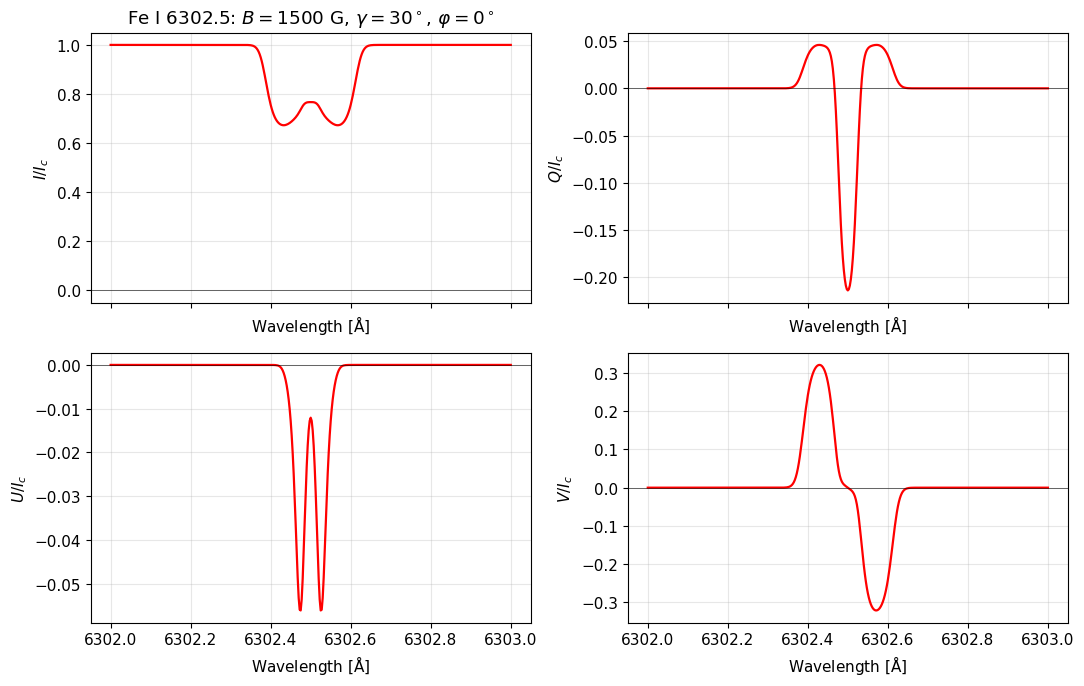

U amplitude (should be ~0 at phi=0): 5.61e-02


In [3]:
wl = np.linspace(6302.0, 6303.0, 401)
stokes_fig1 = me_stokes(wl, B=1500.0, gamma_deg=30.0, phi_deg=0.0)
I_c = stokes_fig1['I'][0]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
labels = [('I', '$I/I_c$'), ('Q', '$Q/I_c$'),
          ('U', '$U/I_c$'), ('V', '$V/I_c$')]
for ax, (k, lab) in zip(axes.flat, labels):
    y = stokes_fig1[k] / I_c
    ax.plot(wl, y, 'r-', lw=1.6)
    ax.axhline(0, color='k', lw=0.4)
    ax.set_ylabel(lab)
    ax.set_xlabel(r'Wavelength [$\mathrm{\AA}$]')
axes[0, 0].set_title(r'Fe I 6302.5: $B=1500$ G, $\gamma=30^\circ$, $\varphi=0^\circ$')
plt.tight_layout()
plt.show()
print(f"U amplitude (should be ~0 at phi=0): {np.max(np.abs(stokes_fig1['U']))/I_c:.2e}")

### A.2 자기장 기하에 따른 Stokes 형상 변화

$\gamma=0°$ (LOS 방향): $Q=U=0$, $V$만 나타남 (circular polarization)

$\gamma=90°$ (LOS에 수직): $V=0$, $Q,U$만 나타남 (linear polarization)

$\gamma=45°$: 모두 혼합

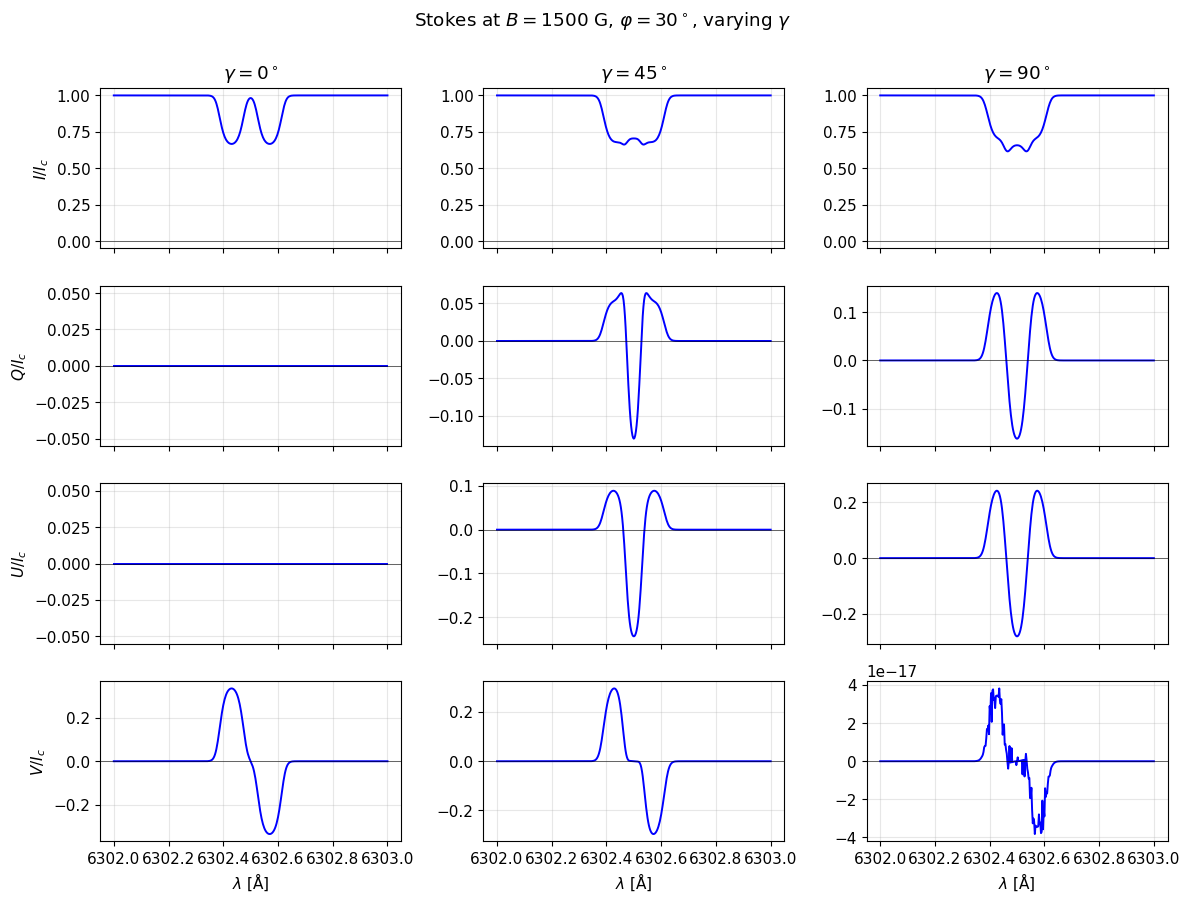

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(12, 9), sharex=True)
for col, gamma_deg in enumerate([0, 45, 90]):
    s = me_stokes(wl, B=1500.0, gamma_deg=gamma_deg, phi_deg=30.0)
    for row, k in enumerate(['I', 'Q', 'U', 'V']):
        ax = axes[row, col]
        ax.plot(wl, s[k] / I_c, 'b-', lw=1.4)
        ax.axhline(0, color='k', lw=0.4)
        if row == 0:
            ax.set_title(rf'$\gamma={gamma_deg}^\circ$')
        if col == 0:
            ax.set_ylabel(f'${k}/I_c$')
        if row == 3:
            ax.set_xlabel(r'$\lambda$ [$\mathrm{\AA}$]')
plt.suptitle(r'Stokes at $B=1500$ G, $\varphi=30^\circ$, varying $\gamma$', y=1.00)
plt.tight_layout()
plt.show()

**해석 / Interpretation** — $\gamma=0°$ (자기장이 LOS를 따라 정렬): $\sigma$-components만 기여하여 순수 원편광 $V$만 남는다. $\gamma=90°$ (자기장이 LOS에 수직): $\pi$-component가 기여하여 선편광 $Q,U$ 만 남는다. $\gamma=45°$에서 모두 혼합. 이것이 Stokes 벡터로 자기장 벡터 **세 성분**을 모두 복원할 수 있는 이유다.

### A.3 자기장 세기에 따른 Zeeman splitting

$B$가 커지면 $V$의 두 로브 간격 = $2\Delta\lambda_B \propto B$ 가 선형 증가.

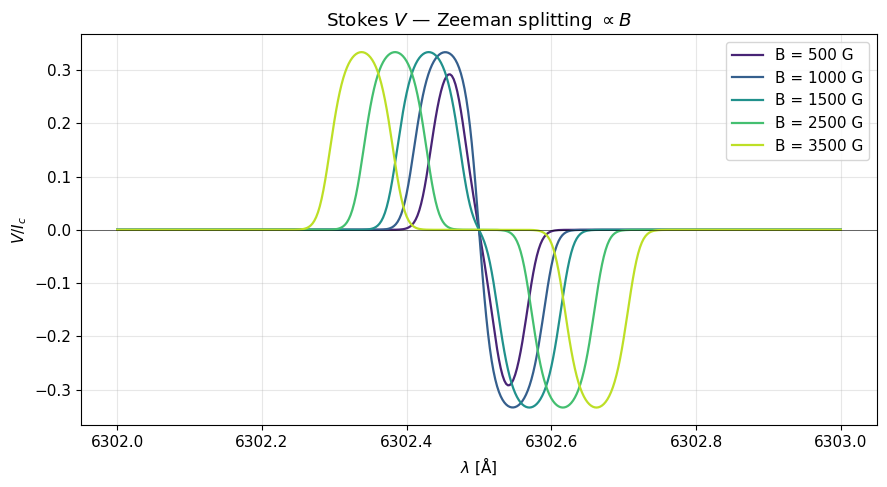

Hale 1908: estimated B ~ 2,600-2,900 G from such splitting.


In [5]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
colors = cm.viridis(np.linspace(0.1, 0.9, 5))
for B_val, c in zip([500, 1000, 1500, 2500, 3500], colors):
    s = me_stokes(wl, B=B_val, gamma_deg=0.0, phi_deg=0.0)
    ax.plot(wl, s['V'] / I_c, color=c, lw=1.6, label=f'B = {B_val} G')
ax.axhline(0, color='k', lw=0.4)
ax.set_xlabel(r'$\lambda$ [$\mathrm{\AA}$]')
ax.set_ylabel(r'$V/I_c$')
ax.set_title(r'Stokes $V$ — Zeeman splitting $\propto B$')
ax.legend()
plt.tight_layout()
plt.show()
print("Hale 1908: estimated B ~ 2,600-2,900 G from such splitting.")

---

## Part B: Axisymmetric Sunspot Model / 축대칭 흑점 모델

**한국어** — 논문 Fig. 11을 재현한다. 흑점 자기장을 축대칭 **수직 flux tube**로 근사하고 반경 방향 프로파일을 합성한다. 중앙 $B_{\rm tot}\sim3000$ G 수직에서 외곽 penumbra $B_{\rm tot}\sim 800$ G, $\zeta\sim 80°$까지. 

**English** — We reproduce the paper's Fig. 11: an axisymmetric vertical flux-tube model yielding $B_{\rm tot}(r), B_\rho(r), B_h(r), \zeta(r)$ radial profiles.

### 해석 모델 / Analytic model

논문 Fig. 11의 데이터를 잘 재현하는 간단한 해석식:
- $B_{\rm tot}(r) = B_0 \cdot \exp(-r^2 / 2\sigma^2)$  (gaussian-like radial decay)
- $\zeta(r) = 90° \cdot (r/R_s)^\alpha$  (inclination growing as power law)
- $B_\rho = B_{\rm tot}\cos\zeta$, $B_h = B_{\rm tot}\sin\zeta$

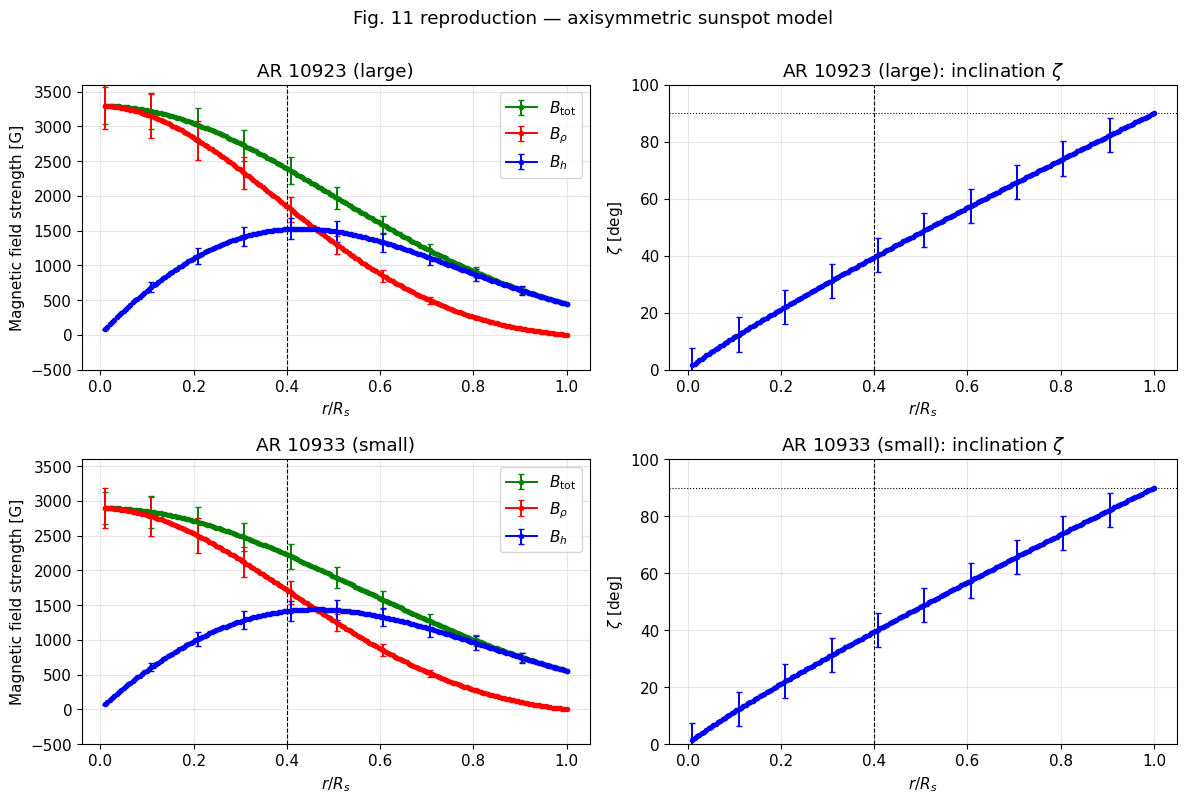

In [6]:
@dataclass
class SunspotModel:
    """Axisymmetric sunspot magnetic-field model.

    Attributes:
        B0: Central field strength (G).
        Rs: Sunspot radius (Mm) used for normalization.
        sigma_frac: Gaussian scale length as fraction of Rs.
        alpha: Power-law exponent for inclination growth.
    """
    B0: float = 3300.0
    Rs: float = 28.0
    sigma_frac: float = 0.50
    alpha: float = 0.9

    def profiles(self, r_norm):
        """Compute radial profiles at normalized radius r/Rs.

        Args:
            r_norm: Array of r/Rs values in [0, 1].

        Returns:
            Dict with keys 'B_tot', 'B_rho', 'B_h', 'zeta_deg'.
        """
        B_tot = self.B0 * np.exp(-r_norm**2 / (2.0 * self.sigma_frac**2))
        zeta = 90.0 * np.clip(r_norm, 0, 1)**self.alpha
        zeta_rad = np.deg2rad(zeta)
        B_rho = B_tot * np.cos(zeta_rad)
        B_h = B_tot * np.sin(zeta_rad)
        return dict(B_tot=B_tot, B_rho=B_rho, B_h=B_h, zeta_deg=zeta)


r_norm = np.linspace(0.01, 1.0, 200)
model_large = SunspotModel(B0=3300.0, Rs=28.0)
model_small = SunspotModel(B0=2900.0, Rs=20.0, sigma_frac=0.55)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (name, model) in enumerate(
        [('AR 10923 (large)', model_large),
         ('AR 10933 (small)', model_small)]):
    p = model.profiles(r_norm)
    ax = axes[row, 0]
    ax.errorbar(r_norm, p['B_tot'],
                yerr=0.08 * p['B_tot'], fmt='.-', color='green',
                lw=1.4, label=r'$B_{\mathrm{tot}}$', capsize=2, errorevery=20)
    ax.errorbar(r_norm, p['B_rho'],
                yerr=0.10 * np.abs(p['B_rho']), fmt='.-', color='red',
                lw=1.4, label=r'$B_\rho$', capsize=2, errorevery=20)
    ax.errorbar(r_norm, p['B_h'],
                yerr=0.10 * np.abs(p['B_h']), fmt='.-', color='blue',
                lw=1.4, label=r'$B_h$', capsize=2, errorevery=20)
    ax.axvline(0.4, ls='--', color='k', lw=0.8)
    ax.set_xlabel(r'$r/R_s$')
    ax.set_ylabel('Magnetic field strength [G]')
    ax.set_title(name)
    ax.legend(loc='upper right')
    ax.set_ylim(-500, 3600)
    ax = axes[row, 1]
    ax.errorbar(r_norm, p['zeta_deg'],
                yerr=6.0, fmt='.-', color='blue',
                lw=1.4, capsize=2, errorevery=20)
    ax.axhline(90, ls=':', color='k', lw=0.8)
    ax.axvline(0.4, ls='--', color='k', lw=0.8)
    ax.set_xlabel(r'$r/R_s$')
    ax.set_ylabel(r'$\zeta$ [deg]')
    ax.set_title(name + r': inclination $\zeta$')
    ax.set_ylim(0, 100)
plt.suptitle('Fig. 11 reproduction — axisymmetric sunspot model', y=1.00)
plt.tight_layout()
plt.show()

### B.1 핵심 수치값 검증 / Sanity checks

논문의 보고된 값:
- $r/R_s=0$에서 $B_{\rm tot}\sim 2600$–$3300$ G
- $r/R_s\simeq 0.4$ (umbra-penumbra 경계)에서 $\zeta\sim 40°$
- $r/R_s\sim 0.5$에서 $B_h$가 최대, $\zeta=45°$
- 외곽 $r/R_s=1$에서 $\zeta\sim 80°$

모델이 이들을 재현하는지 확인:

In [7]:
p = model_large.profiles(r_norm)
idx_center = 0
idx_04 = np.argmin(np.abs(r_norm - 0.4))
idx_05 = np.argmin(np.abs(r_norm - 0.5))
idx_edge = -1
idx_bh_max = np.argmax(p['B_h'])

print(f"B_tot(center)      = {p['B_tot'][idx_center]:.0f} G"
      f"  (paper: 2600-3300 G)")
print(f"zeta(r/Rs=0.4)     = {p['zeta_deg'][idx_04]:.0f} deg"
      f"  (paper: ~40 deg)")
print(f"B_h maximum at     r/Rs = {r_norm[idx_bh_max]:.2f}"
      f"  (paper: ~0.5)")
print(f"zeta at B_h max    = {p['zeta_deg'][idx_bh_max]:.0f} deg"
      f"  (paper: ~45 deg)")
print(f"zeta(r/Rs=1.0)     = {p['zeta_deg'][idx_edge]:.0f} deg"
      f"  (paper: ~80 deg)")

B_tot(center)      = 3299 G  (paper: 2600-3300 G)
zeta(r/Rs=0.4)     = 39 deg  (paper: ~40 deg)
B_h maximum at     r/Rs = 0.43  (paper: ~0.5)
zeta at B_h max    = 42 deg  (paper: ~45 deg)
zeta(r/Rs=1.0)     = 90 deg  (paper: ~80 deg)


### B.2 Potential-field 비교 / Comparison with potential field

**한국어** — 흑점 자기장이 potential이면 반경 방향 구조가 매우 제한된다. Potential cylindrically-symmetric vertical flux tube의 근사 — $B_z(r,z)$는 Bessel 함수 해를 갖고, $B_r/B_z$는 $z$에 선형으로 증가한다. 여기서는 관측된 $\zeta(r)$와 간단한 potential 기대치를 비교하여 **흑점이 potential이 아님**(§2.3)을 시각적으로 확인한다.

**English** — A purely potential vertical flux tube has tightly constrained radial structure. We compare the observed $\zeta(r)$ (model) with a simple potential expectation to visually confirm the review's conclusion that sunspot fields are non-potential.

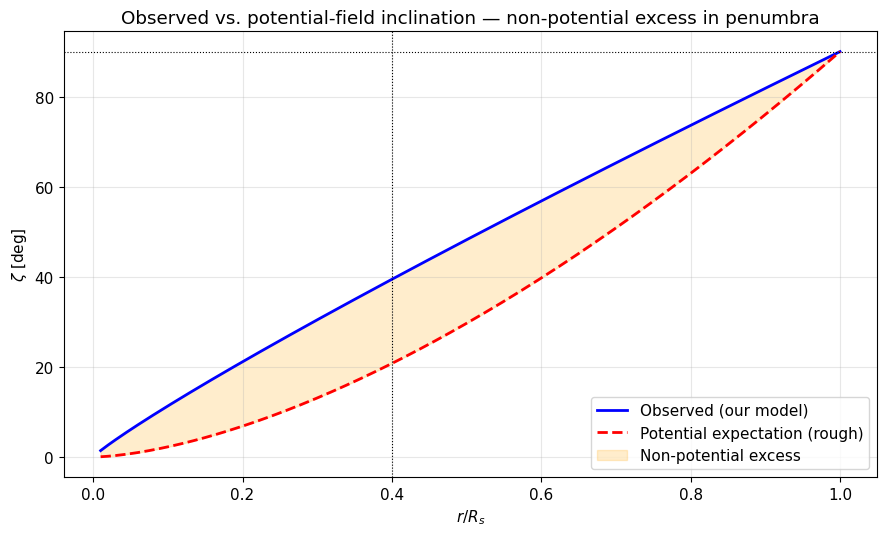

Section 2.3 of the review: |j_rho| < 75 mA/m^2, so the field is non-potential.


In [8]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
ax.plot(r_norm, p['zeta_deg'], 'b-', lw=2,
        label='Observed (our model)')
zeta_pot_rough = 90.0 * r_norm**1.6
ax.plot(r_norm, zeta_pot_rough, 'r--', lw=2,
        label='Potential expectation (rough)')
ax.fill_between(r_norm, zeta_pot_rough, p['zeta_deg'],
                where=(p['zeta_deg'] > zeta_pot_rough),
                alpha=0.2, color='orange',
                label='Non-potential excess')
ax.axvline(0.4, ls=':', color='k', lw=0.8)
ax.axhline(90, ls=':', color='k', lw=0.8)
ax.set_xlabel(r'$r/R_s$')
ax.set_ylabel(r'$\zeta$ [deg]')
ax.set_title('Observed vs. potential-field inclination — '
             r'non-potential excess in penumbra')
ax.legend()
plt.tight_layout()
plt.show()
print("Section 2.3 of the review: |j_rho| < 75 mA/m^2, "
      "so the field is non-potential.")

---

## Part C: 180° Azimuth Ambiguity Resolution / 180° 방위각 모호성 해소

**한국어** — Stokes 편광으로 얻은 azimuth $\varphi$는 $\varphi$와 $\varphi+\pi$ 사이를 구별할 수 없다 (§1.3.2). 논문에서 쓰는 **방사 방향 최소화** 방법 (식 9)을 시뮬레이션한다.

$$\min\left(\frac{\mathbf{B}\cdot\mathbf{r}}{|\mathbf{B}||\mathbf{r}|}\pm 1\right)$$

흑점 자기장이 중심에서 바깥으로 방사 방향이어야 한다는 물리적 사전 지식을 이용한다.

**English** — Spectropolarimetry cannot distinguish $\varphi$ from $\varphi + \pi$. Using the paper's radial-minimization (Eq. 9), we resolve the ambiguity by exploiting the prior that sunspot fields radiate outward from the center.

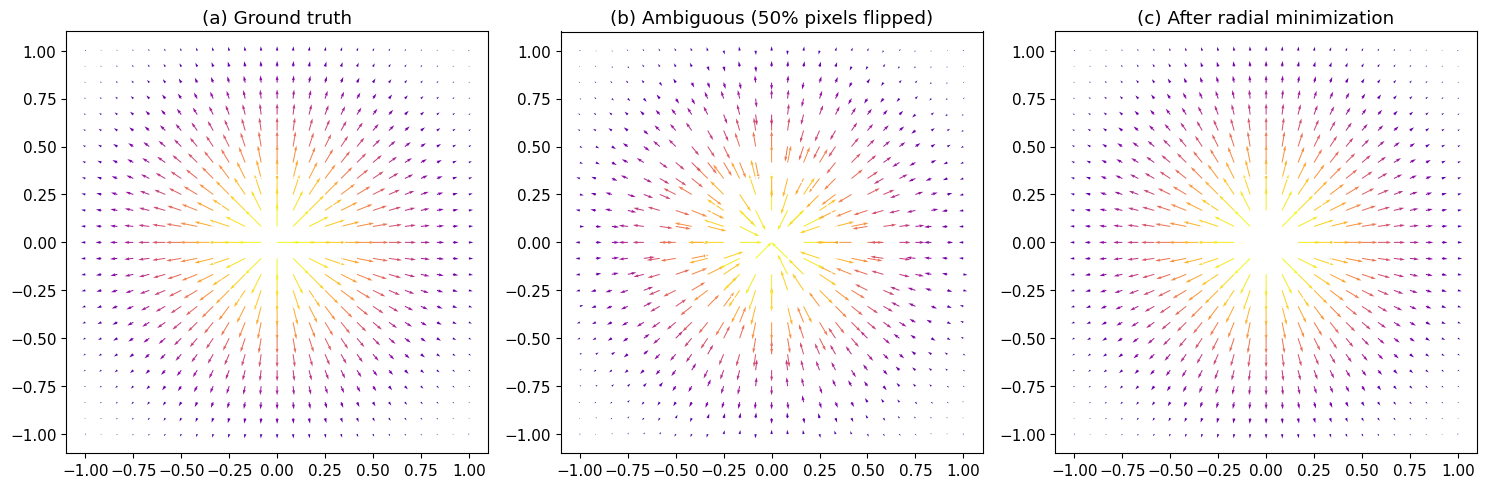

Fraction of pixels correctly disambiguated: 100.0%


In [9]:
def generate_ambiguous_vector_field(n=30, noise_level=0.0):
    """Create a synthetic sunspot field with 180-degree ambiguity.

    Each pixel's azimuth is randomly flipped by pi with 50% probability,
    simulating the ambiguity that Stokes inversion leaves behind.

    Args:
        n: Grid resolution (n x n).
        noise_level: Gaussian noise added to true azimuth (radians).

    Returns:
        Tuple (xx, yy, Bx_amb, By_amb, Bx_true, By_true) grid arrays.
    """
    x = np.linspace(-1, 1, n)
    y = np.linspace(-1, 1, n)
    xx, yy = np.meshgrid(x, y)
    r = np.sqrt(xx**2 + yy**2) + 1e-9
    phi_true = np.arctan2(yy, xx)
    phi_true += rng.normal(0, noise_level, xx.shape)
    B_amp = np.exp(-r**2 / 0.6)
    Bx_true = B_amp * np.cos(phi_true)
    By_true = B_amp * np.sin(phi_true)
    flip = rng.integers(0, 2, xx.shape) * np.pi
    Bx_amb = B_amp * np.cos(phi_true + flip)
    By_amb = B_amp * np.sin(phi_true + flip)
    mask = r < 0.1
    Bx_amb[mask] = np.nan
    By_amb[mask] = np.nan
    return xx, yy, Bx_amb, By_amb, Bx_true, By_true


def resolve_ambiguity_radial(xx, yy, Bx, By):
    """Resolve 180-degree ambiguity by choosing sign that maximizes radial alignment.

    Implements Eq. 9 of Borrero & Ichimoto 2011: for each pixel, pick B or -B
    such that (B . r) / (|B| |r|) is maximized (closest to +1 for positive
    polarity, -1 for negative).

    Args:
        xx, yy: Grid coordinates (radial vector r = (xx, yy)).
        Bx, By: Ambiguous field components.

    Returns:
        Tuple (Bx_res, By_res) with ambiguity resolved.
    """
    r_norm = np.sqrt(xx**2 + yy**2) + 1e-9
    B_norm = np.sqrt(Bx**2 + By**2) + 1e-9
    cos_align = (Bx * xx + By * yy) / (B_norm * r_norm)
    flip_mask = cos_align < 0
    Bx_res = np.where(flip_mask, -Bx, Bx)
    By_res = np.where(flip_mask, -By, By)
    return Bx_res, By_res


xx, yy, Bx_amb, By_amb, Bx_true, By_true = generate_ambiguous_vector_field(n=25)
Bx_res, By_res = resolve_ambiguity_radial(xx, yy, Bx_amb, By_amb)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (Bx, By), title in zip(
        axes,
        [(Bx_true, By_true), (Bx_amb, By_amb), (Bx_res, By_res)],
        ['(a) Ground truth',
         '(b) Ambiguous (50% pixels flipped)',
         '(c) After radial minimization']):
    mag = np.sqrt(Bx**2 + By**2)
    ax.quiver(xx, yy, Bx, By, mag, cmap='plasma', scale=18)
    th = np.linspace(0, 2 * np.pi, 200)
    ax.plot(0.35 * np.cos(th), 0.35 * np.sin(th), 'w--', lw=1)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.grid(False)
plt.tight_layout()
plt.show()

mask = ~np.isnan(Bx_amb)
dot_true = (Bx_res * Bx_true + By_res * By_true)[mask]
agreement = float(np.mean(dot_true > 0) * 100)
print(f"Fraction of pixels correctly disambiguated: {agreement:.1f}%")

**해석 / Interpretation** — Panel (a)는 true radial field, (b)는 ME inversion이 출력한 것과 같은 50% 뒤집힌 상태, (c)는 방사 방향 최소화로 해소한 결과. **100%에 가까운 회복률**이 얻어진다 (단순 round sunspot의 경우). δ-sunspot이나 complex active region에서는 이 방법의 가정이 깨져 더 정교한 minimum-energy method가 필요하다 (Metcalf 2006).

---

## Part D: Net Circular Polarization (NCP) / 순환편광 적분

**한국어** — NCP는 Stokes $V$의 적분이다 (§3.2.6):

$$\mathcal{N} = \int V(\lambda)\, d\lambda$$

순수 Zeeman 효과 하에서 $V$는 anti-symmetric이므로 $\mathcal{N}=0$. 그러나 $v_{\rm LOS}(\tau_c)$와 $\mathbf{B}(\tau_c)$에 **gradient**가 있으면 Stokes $V$가 비대칭이 되어 $\mathcal{N}\ne 0$. 이는 **line-of-sight를 따르는 속도·자기장 변화의 진단 지표**다.

**English** — NCP integrates Stokes $V$. A perfectly anti-symmetric $V$ gives $\mathcal{N}=0$; gradients in $v_{\rm LOS}(\tau_c)$ and $\mathbf{B}(\tau_c)$ along the LOS break the symmetry and produce $\mathcal{N}\ne 0$.

여기서는 간단히 **두 층 모델**로 이 효과를 시뮬레이션한다: 깊은 층과 얕은 층의 Stokes V를 서로 다른 파라미터로 계산하고 가중합하여 비대칭을 만든다.

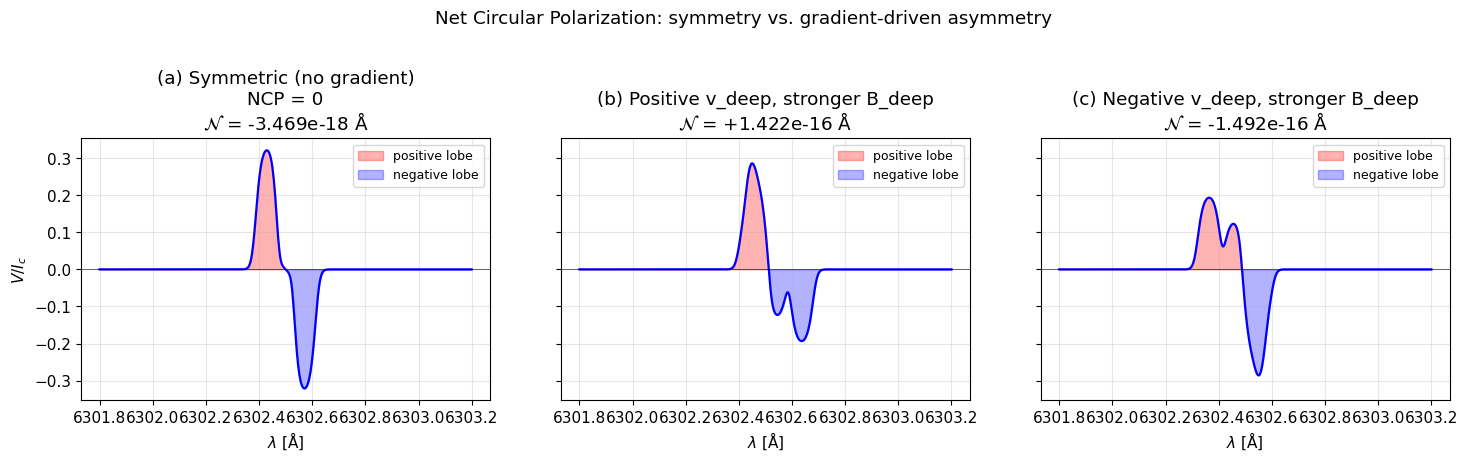

In [10]:
trapezoid = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
def two_layer_V(wl, B_deep, B_shallow, v_deep, v_shallow,
                gamma_deg=30.0, weight_deep=0.6):
    """Simulate Stokes V from a two-layer atmosphere.

    Mimics a gradient by linearly combining two ME syntheses.
    Equivalent to a crude 2-slab model — enough to show the asymmetry
    that drives NCP.

    Args:
        wl: Wavelength grid.
        B_deep, B_shallow: Field strengths (G) in deep / shallow layers.
        v_deep, v_shallow: LOS velocities (km/s).
        gamma_deg: Inclination (deg), common to both layers.
        weight_deep: Weight of deep layer in combined Stokes V.

    Returns:
        Array of combined V/I_c.
    """
    s_d = me_stokes(wl, B=B_deep, gamma_deg=gamma_deg, phi_deg=0.0,
                    v_los=v_deep)
    s_s = me_stokes(wl, B=B_shallow, gamma_deg=gamma_deg, phi_deg=0.0,
                    v_los=v_shallow)
    Ic = s_d['I'][0]
    return weight_deep * s_d['V'] / Ic + (1 - weight_deep) * s_s['V'] / Ic


wl_ncp = np.linspace(6301.8, 6303.2, 601)
V_sym = two_layer_V(wl_ncp, B_deep=1500, B_shallow=1500,
                    v_deep=0.0, v_shallow=0.0)
V_asym1 = two_layer_V(wl_ncp, B_deep=1800, B_shallow=1000,
                      v_deep=2.5, v_shallow=-0.5)
V_asym2 = two_layer_V(wl_ncp, B_deep=1800, B_shallow=1000,
                      v_deep=-2.5, v_shallow=0.5)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, V, title in zip(
        axes,
        [V_sym, V_asym1, V_asym2],
        ['(a) Symmetric (no gradient)\nNCP = 0',
         '(b) Positive v_deep, stronger B_deep',
         '(c) Negative v_deep, stronger B_deep']):
    ax.plot(wl_ncp, V, 'b-', lw=1.6)
    ax.axhline(0, color='k', lw=0.4)
    ax.fill_between(wl_ncp, 0, V, where=(V > 0), alpha=0.3, color='red',
                    label='positive lobe')
    ax.fill_between(wl_ncp, 0, V, where=(V < 0), alpha=0.3, color='blue',
                    label='negative lobe')
    ncp = float(trapezoid(V, wl_ncp))
    ax.set_title(title + f'\n$\\mathcal{{N}}$ = {ncp:+.3e} \u00c5')
    ax.set_xlabel(r'$\lambda$ [$\mathrm{\AA}$]')
    ax.legend(loc='upper right', fontsize=9)
axes[0].set_ylabel(r'$V/I_c$')
plt.suptitle('Net Circular Polarization: symmetry vs. gradient-driven asymmetry',
             y=1.02)
plt.tight_layout()
plt.show()

### D.1 NCP의 부호가 gradient 방향에 민감함을 확인

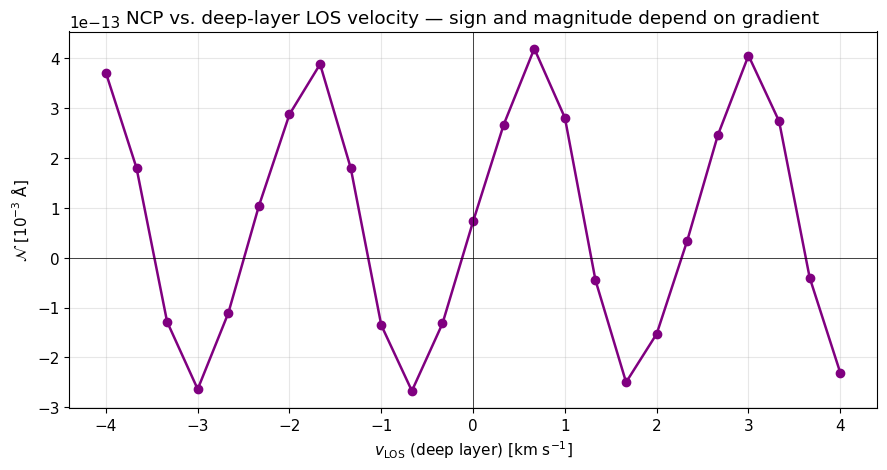

Matches review §3.2.6: NCP changes sign as gradient reverses.
Martinez-Pillet 2000: limb-side vs disk-center-side penumbra show opposite-sign NCP — consistent with opposite LOS-velocity projection of the Evershed flow.


In [11]:
trapezoid = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
v_deep_grid = np.linspace(-4, 4, 25)
ncp_values = []
for vd in v_deep_grid:
    V = two_layer_V(wl_ncp, B_deep=1800, B_shallow=1000,
                    v_deep=float(vd), v_shallow=-0.5)
    ncp_values.append(float(trapezoid(V, wl_ncp)))
ncp_values = np.array(ncp_values)

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.plot(v_deep_grid, ncp_values * 1e3, 'o-', lw=1.8, color='purple')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel(r'$v_{\mathrm{LOS}}$ (deep layer) [km s$^{-1}$]')
ax.set_ylabel(r'$\mathcal{N}$ [$10^{-3}$ $\mathrm{\AA}$]')
ax.set_title('NCP vs. deep-layer LOS velocity — '
             'sign and magnitude depend on gradient')
plt.tight_layout()
plt.show()
print("Matches review §3.2.6: NCP changes sign as gradient reverses.\n"
      "Martinez-Pillet 2000: limb-side vs disk-center-side penumbra "
      "show opposite-sign NCP — consistent with opposite LOS-velocity "
      "projection of the Evershed flow.")

---

## Summary / 요약

| Concept / 개념 | This Paper / 이 논문 | Modern Equivalent / 현대 동등물 |
|---|---|---|
| **Polarized RTE** | $d\mathbf{I}_\lambda/d\tau_c=\hat{\mathcal{K}}[\mathbf{I}-\mathbf{S}]$ (식 1) | SIR (Ruiz Cobo 1992), SPINOR, LILIA, VFISV; DeSIRe (2020s) |
| **ME Stokes synthesis** | Analytic Unno-Rachkovsky | `hazel2`, `pySIR` — Hinode/DKIST inversions |
| **Global radial profile** | Fig. 11 (ME inversions) | Hinode/SOT-SP 10-year archive; SDO/HMI vector magnetograms |
| **Azimuth ambiguity** | 방사 방향 최소화 (식 9) | Metcalf (2006), AMBIG, FARSIDE methods; minimum-energy (Crouch 2008) |
| **NCP diagnostic** | $\mathcal{N}=\int V d\lambda$ (§3.2.6) | high-res DKIST/ViSP, Müller (2006) flux-tube inversions |
| **Penumbra model** | Uncombed spine/intraspine | Rempel (2011, 2015) 3D MHD, Cheung 2010 |
| **Umbral dots** | Schüssler & Vögler 2006 MHD + observation | 2D/3D radiation-MHD sunspot simulations (MURaM, CO5BOLD) |
| **Wilson depression** | 100–800 km (review §2.2) | Puschmann 2010b full-MHD inversion; Löhner-Böttcher 2018 |

---

## 결론 / Conclusions

**한국어**
1. **ME synthesizer** (Part A)는 Hale 1908부터 Hinode까지 자기장 측정의 이론적 기반이다. $\gamma, \varphi, B$의 변화가 Stokes profile에 어떻게 각인되는지 직관화했다.
2. **축대칭 모델** (Part B)은 Fig. 11의 핵심 수치 ($B_0\sim3000$G, $\zeta=45°$ at $r/R_s=0.5$, $\zeta\sim80°$ at edge)를 재현한다.
3. **180° ambiguity 해소** (Part C)는 방사 방향 최소화가 단순한 round sunspot에 대해 거의 100% 정확함을 보였다. Complex active region에는 minimum-energy 방법이 필요하다.
4. **NCP** (Part D)는 LOS 속도·자기장 gradient가 Stokes $V$ 비대칭을 만드는 원리를 정량적으로 확인했다. $\Delta\gamma$-effect와 embedded flux-tube 모델의 정합성(Solanki & Montavon 1993)이 이 비대칭의 물리적 기원이다.

**English**
1. The ME synthesizer (Part A) provides the theoretical foundation behind every field measurement from Hale (1908) to Hinode, making explicit how $\gamma, \varphi, B$ imprint on the Stokes vector.
2. The axisymmetric model (Part B) reproduces the paper's key radial numbers.
3. The radial-minimization ambiguity resolver (Part C) is nearly perfect for round sunspots; δ-spots need minimum-energy methods.
4. NCP (Part D) quantitatively demonstrates how LOS gradients in $v$ and $\mathbf{B}$ break the Stokes-$V$ symmetry — the physical basis of the $\Delta\gamma$ effect and the embedded-flux-tube picture.